In [1]:
# Importation des bibliothèques nécessaires
import numpy as np  # NumPy est utilisé pour les calculs mathématiques et la manipulation de tableaux
import matplotlib.pyplot as plt  # Matplotlib est utilisé pour visualiser les données
def sklearn.linear_model import LinearRegression, LogisticRegression  # Scikit-learn offre des implémentations prêtes à l'emploi pour la régression linéaire et logistique
from sklearn.preprocessing import PolynomialFeatures  # Utilisé pour générer des caractéristiques polynomiales
from sklearn.metrics import mean_squared_error, accuracy_score  

Matplotlib is building the font cache; this may take a moment.


In [2]:
# -----------------------------
# 1. Linear Regression (from scratch)
# -----------------------------
class LinearRegressionScratch:
    def __init__(self):
        self.weights = None

    def fit(self, X, y, learning_rate=0.01, epochs=1000):
        X = np.c_[np.ones(X.shape[0]), X]  # Ajoute un terme d'interception aux caractéristiques
        self.weights = np.zeros(X.shape[1])  # Initialise les poids à zéro

        for epoch in range(epochs):
            predictions = X.dot(self.weights)  # Calcule les prédictions actuelles
            errors = predictions - y  # Calcule les erreurs entre les prédictions et les vraies valeurs
            gradient = X.T.dot(errors) / len(y)  # Calcule le gradient pour la descente de gradient
            self.weights -= learning_rate * gradient  # Met à jour les poids

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]  # Ajoute un terme d'interception aux caractéristiques
        return X.dot(self.weights)  # Calcule les prédictions finales

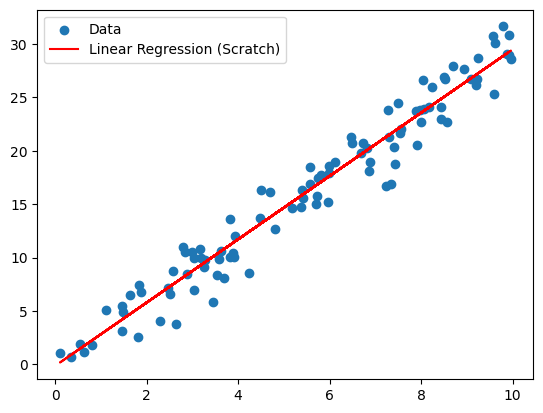

In [3]:
# Test Linear Regression (from scratch)
X = np.random.rand(100, 1) * 10  # Génère des données aléatoires pour la variable indépendante
y = 3 * X.flatten() + np.random.randn(100) * 2  # Génère des données dépendantes avec un peu de bruit

model_scratch = LinearRegressionScratch()
model_scratch.fit(X, y)  # Entraîne le modèle
predictions = model_scratch.predict(X)  # Fait des prédictions

plt.scatter(X, y, label='Data')  # Affiche les données d'origine
plt.plot(X, predictions, color='red', label='Linear Regression (Scratch)')  # Affiche les prédictions du modèle
plt.legend()
plt.show()

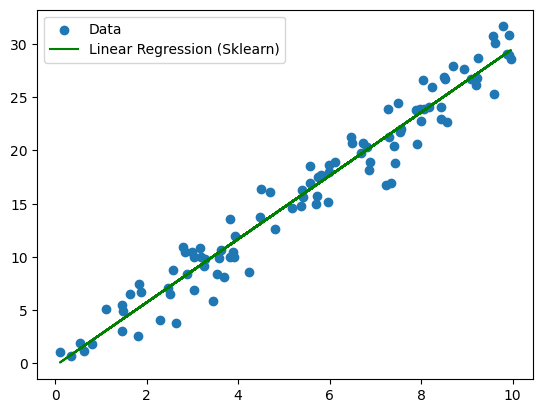

In [4]:
# -----------------------------
# 2. Linear Regression (Scikit-learn)
# -----------------------------
model_sklearn = LinearRegression()  # Initialise le modèle Scikit-learn
model_sklearn.fit(X, y)  # Entraîne le modèle
sklearn_predictions = model_sklearn.predict(X)  # Fait des prédictions

plt.scatter(X, y, label='Data')  # Affiche les données d'origine
plt.plot(X, sklearn_predictions, color='green', label='Linear Regression (Sklearn)')  # Affiche les prédictions
plt.legend()
plt.show()

In [5]:
# 3. Polynomial Regression (from scratch)
# -----------------------------
class PolynomialRegressionScratch:
    def __init__(self, degree):
        self.degree = degree  # Définit le degré du polynôme
        self.linear_model = LinearRegressionScratch()  # Utilise la régression linéaire 'from scratch' pour ajuster

    def fit(self, X, y, learning_rate=0.01, epochs=1000):
        poly_features = self._generate_polynomial_features(X)  # Génère les caractéristiques polynomiales
        self.linear_model.fit(poly_features, y, learning_rate, epochs)  # Entraîne le modèle

    def predict(self, X):
        poly_features = self._generate_polynomial_features(X)  # Génère les caractéristiques pour les nouvelles données
        return self.linear_model.predict(poly_features)  # Prédictions basées sur les caractéristiques polynomiales

    def _generate_polynomial_features(self, X):
        poly_features = X
        for power in range(2, self.degree + 1):
            poly_features = np.c_[poly_features, X ** power]  # Ajoute des termes au polynôme
        return np.c_[np.ones(X.shape[0]), poly_features]  # Ajoute un terme d'interception


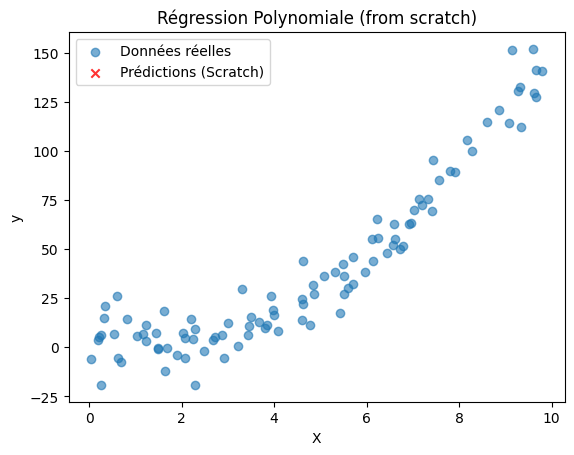

In [17]:
# Test Polynomial Regression (from scratch)
X = np.random.rand(100, 1) * 10  # Génère des données aléatoires
y = 2 * X.flatten()**2 - 5 * X.flatten() + 3 + np.random.randn(100) * 10  # Génère des données dépendantes polynomiales avec bruit

poly_model_scratch = PolynomialRegressionScratch(degree=2)
poly_model_scratch.fit(X, y)  # Entraîne le modèle
poly_predictions = poly_model_scratch.predict(X)  # Fait des prédictions

plt.scatter(X, y, label='Données réelles', alpha=0.6)  # Scatter plot for actual data
plt.scatter(X, poly_predictions, color='red', marker='x', label='Prédictions (Scratch)', alpha=0.8)  # Predictions in red
plt.legend()
plt.title("Régression Polynomiale (from scratch)")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

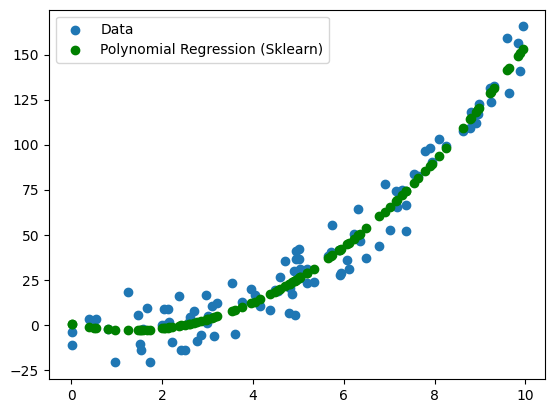

In [12]:
# -----------------------------
# 4. Polynomial Regression (Scikit-learn)
# -----------------------------
poly_transform = PolynomialFeatures(degree=2)  # Initialise le transformateur pour les caractéristiques polynomiales
X_poly = poly_transform.fit_transform(X)  # Transforme les données d'entrée

poly_model_sklearn = LinearRegression()  # Initialise le modèle de régression linéaire
poly_model_sklearn.fit(X_poly, y)  # Entraîne le modèle avec les caractéristiques polynomiales
sklearn_poly_predictions = poly_model_sklearn.predict(X_poly)  # Fait des prédictions

plt.scatter(X, y, label='Data')  # Affiche les données d'origine
plt.scatter(X, sklearn_poly_predictions, color='green', label='Polynomial Regression (Sklearn)')  # Affiche les prédictions
plt.legend()
plt.show()

In [8]:
# -----------------------------
# 5. Logistic Regression (from scratch)
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))  # Fonction sigmoid pour convertir les valeurs en probabilités

class LogisticRegressionScratch:
    def __init__(self):
        self.weights = None

    def fit(self, X, y, learning_rate=0.01, epochs=1000):
        X = np.c_[np.ones(X.shape[0]), X]  # Ajoute un terme d'interception
        self.weights = np.zeros(X.shape[1])  # Initialise les poids

        for epoch in range(epochs):
            predictions = sigmoid(X.dot(self.weights))  # Calcule les probabilités actuelles
            errors = predictions - y  # Calcule les erreurs
            gradient = X.T.dot(errors) / len(y)  # Calcule le gradient
            self.weights -= learning_rate * gradient  # Met à jour les poids

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]  # Ajoute un terme d'interception
        probabilities = sigmoid(X.dot(self.weights))  # Calcule les probabilités finales
        return (probabilities >= 0.5).astype(int)  # Convertit les probabilités en classes


In [13]:
# Test Logistic Regression (from scratch)
X, y = np.random.rand(100, 2), (np.random.rand(100) > 0.5).astype(int)  # Génère des données aléatoires pour un problème de classification binaire
model_logistic_scratch = LogisticRegressionScratch()
model_logistic_scratch.fit(X, y)  # Entraîne le modèle
logistic_predictions = model_logistic_scratch.predict(X)  # Fait des prédictions

print("Accuracy (Scratch):", accuracy_score(y, logistic_predictions))  # Affiche la précision du modèle 'from scratch'

Accuracy (Scratch): 0.51


In [14]:
# -----------------------------
# 6. Logistic Regression (Scikit-learn)
# -----------------------------
model_logistic_sklearn = LogisticRegression()  # Initialise le modèle Scikit-learn
model_logistic_sklearn.fit(X, y)  # Entraîne le modèle
sklearn_logistic_predictions = model_logistic_sklearn.predict(X)  # Fait des prédictions

print("Accuracy (Scikit-learn):", accuracy_score(y, sklearn_logistic_predictions))  # Affiche la précision du modèle Scikit-learn


Accuracy (Scikit-learn): 0.57
